In [30]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
import seaborn as sns
import fiona

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, f1_score
from imblearn.over_sampling import RandomOverSampler
from pathlib import Path

DATA COLLECTING 

In [31]:
BASE = Path(r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT")
GADM = BASE / r"indonesiaSHPLevel3\gadm41_IDN_3.shp"
GDB_BANYUMAS = BASE / r"2022_RBI25K_KAB_BANYUMAS_KUGI50_20221231.gdb"
GDB_JAKPUS   = BASE / r"kotaAdm.JakartaPusat\2022_RBI25K_JAKPUS.gdb"
GDB_YOGYA    = BASE / r"KotaYogyakarta\KOTA YOGYAKARTA\2022_RBI25K_KOTA_YOGYAKARTA_KUGI50_20221231.gdb"

OUT = BASE / "outputs"
(OUT / "per_region").mkdir(parents=True, exist_ok=True)

1) DATA COLLECTING & CLEANING  → shapefile layer dasar

In [32]:
bms_adm = gpd.read_file(GADM)
bms_adm = bms_adm[bms_adm["NAME_2"] == "Banyumas"].to_crs(32749)
bms_boundary = bms_adm.dissolve(by="NAME_2")

# Layer tematik dari GDB
layer_hijau = ["HUTANLAHANTINGGI_AR_25K","HUTANLAHANRENDAH_AR_25K","HERBADANRUMPUT_AR_25K","HUTANTANAMAN_AR_25K"]
layer_bgn   = ["PERUMAHAN_AR_25K","PERMUKIMAN_AR_25K"]
layer_jln   = "JALAN_LN_25K"

hijau_list = [gpd.read_file(GDB_BANYUMAS, layer=l) for l in layer_hijau]
area_hijau = gpd.GeoDataFrame(pd.concat(hijau_list, ignore_index=True), crs=hijau_list[0].crs).to_crs(32749)

bgn_list   = [gpd.read_file(GDB_BANYUMAS, layer=l) for l in layer_bgn]
bangunan   = gpd.GeoDataFrame(pd.concat(bgn_list, ignore_index=True), crs=bgn_list[0].crs).to_crs(32749)

jalan      = gpd.read_file(GDB_BANYUMAS, layer=layer_jln).to_crs(32749)


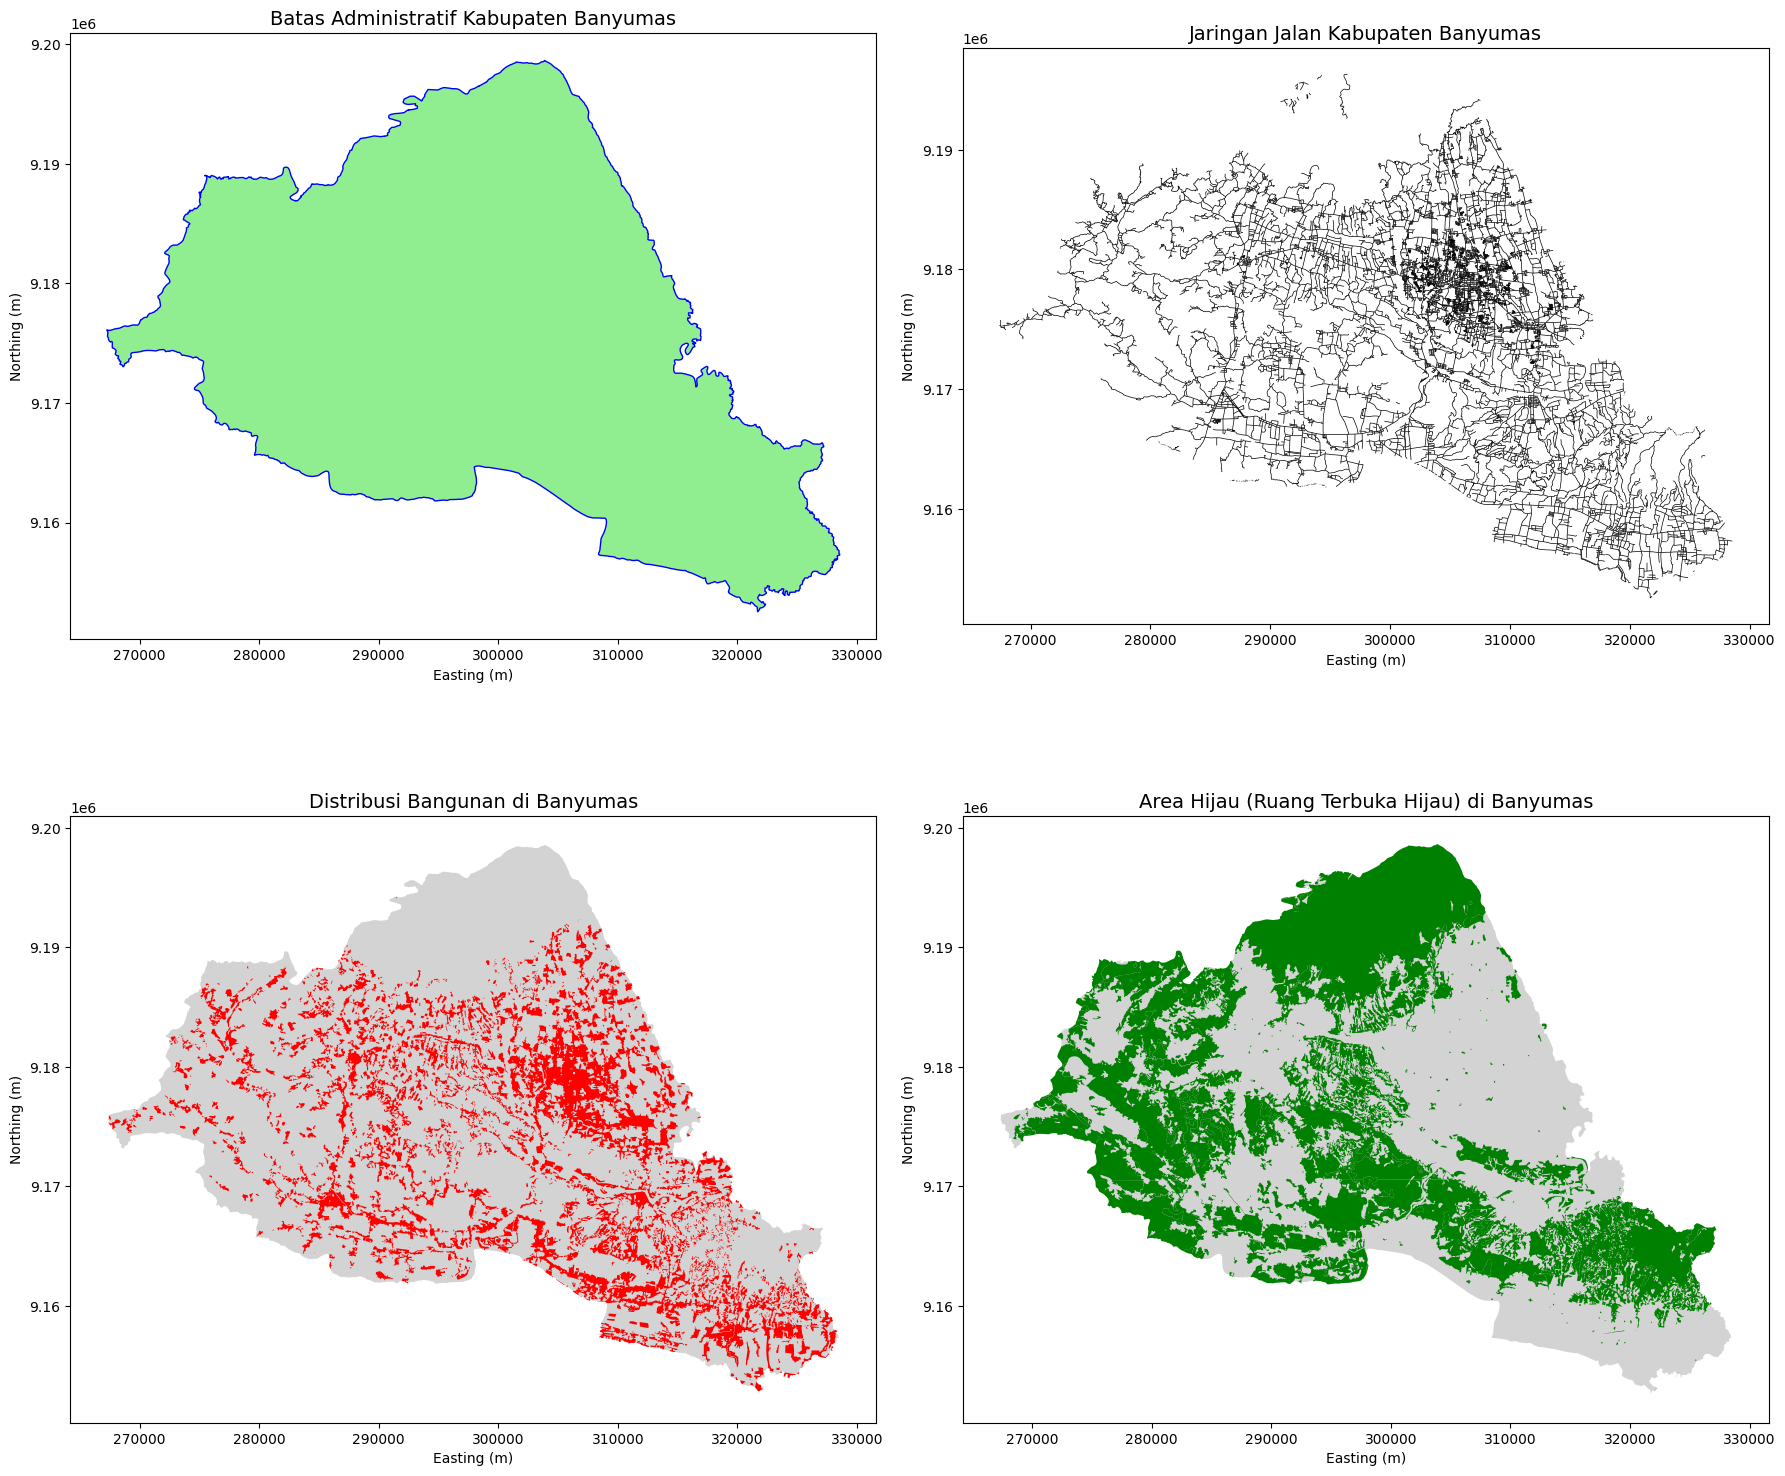

In [34]:
# Clip ke batas Banyumas
area_hijau_bms = gpd.clip(area_hijau, bms_boundary)
bangunan_bms   = gpd.clip(bangunan,   bms_boundary)
jalan_bms      = gpd.clip(jalan,      bms_boundary)

# Visualisasi
fig, axs = plt.subplots(2, 2, figsize=(18, 16))

# Batas Administratif
bms_boundary.plot(ax=axs[0, 0], color="lightgreen", edgecolor="blue")
axs[0, 0].set_title("Batas Administratif Kabupaten Banyumas", fontsize=14)
axs[0, 0].set_xlabel("Easting (m)")
axs[0, 0].set_ylabel("Northing (m)")

# Jaringan Jalan
jalan_bms.plot(ax=axs[0, 1], color="black", linewidth=0.5)
axs[0, 1].set_title("Jaringan Jalan Kabupaten Banyumas", fontsize=14)
axs[0, 1].set_xlabel("Easting (m)")
axs[0, 1].set_ylabel("Northing (m)")

# Distribusi Bangunan
bms_boundary.plot(ax=axs[1, 0], color="lightgrey", edgecolor="white")
bangunan_bms.plot(ax=axs[1, 0], color="red", markersize=0.1)
axs[1, 0].set_title("Distribusi Bangunan di Banyumas", fontsize=14)
axs[1, 0].set_xlabel("Easting (m)")
axs[1, 0].set_ylabel("Northing (m)")

# Area Hijau
bms_boundary.plot(ax=axs[1, 1], color="lightgrey", edgecolor="white")
area_hijau_bms.plot(ax=axs[1, 1], color="green")
axs[1, 1].set_title("Area Hijau (Ruang Terbuka Hijau) di Banyumas", fontsize=14)
axs[1, 1].set_xlabel("Easting (m)")
axs[1, 1].set_ylabel("Northing (m)")

plt.tight_layout()
plt.show()


2) GRID GENERATION → data grid

In [35]:
minx, miny, maxx, maxy = bms_boundary.total_bounds
GRID_SIZE = 500  # m

cols = np.arange(minx, maxx, GRID_SIZE)
rows = np.arange(miny, maxy, GRID_SIZE)

grid_cells = [box(x, y, x + GRID_SIZE, y + GRID_SIZE) for x in cols for y in rows]
grid = gpd.GeoDataFrame({"geometry": grid_cells}, crs=bms_boundary.crs)
grid = gpd.overlay(grid, bms_boundary, how="intersection").reset_index(drop=True)
grid["grid_id"] = np.arange(1, len(grid) + 1)
grid["cell_area_m2"] = grid.geometry.area

# Tambah atribut kecamatan (NAME_3 → kecamatan)
assert "NAME_3" in bms_adm.columns, f"Kolom NAME_3 tidak ada. Kolom tersedia: {bms_adm.columns.tolist()}"
grid = gpd.sjoin(grid, bms_adm[["NAME_3","geometry"]], how="left", predicate="intersects")\
         .rename(columns={"NAME_3":"kecamatan"}).drop(columns=["index_right"])


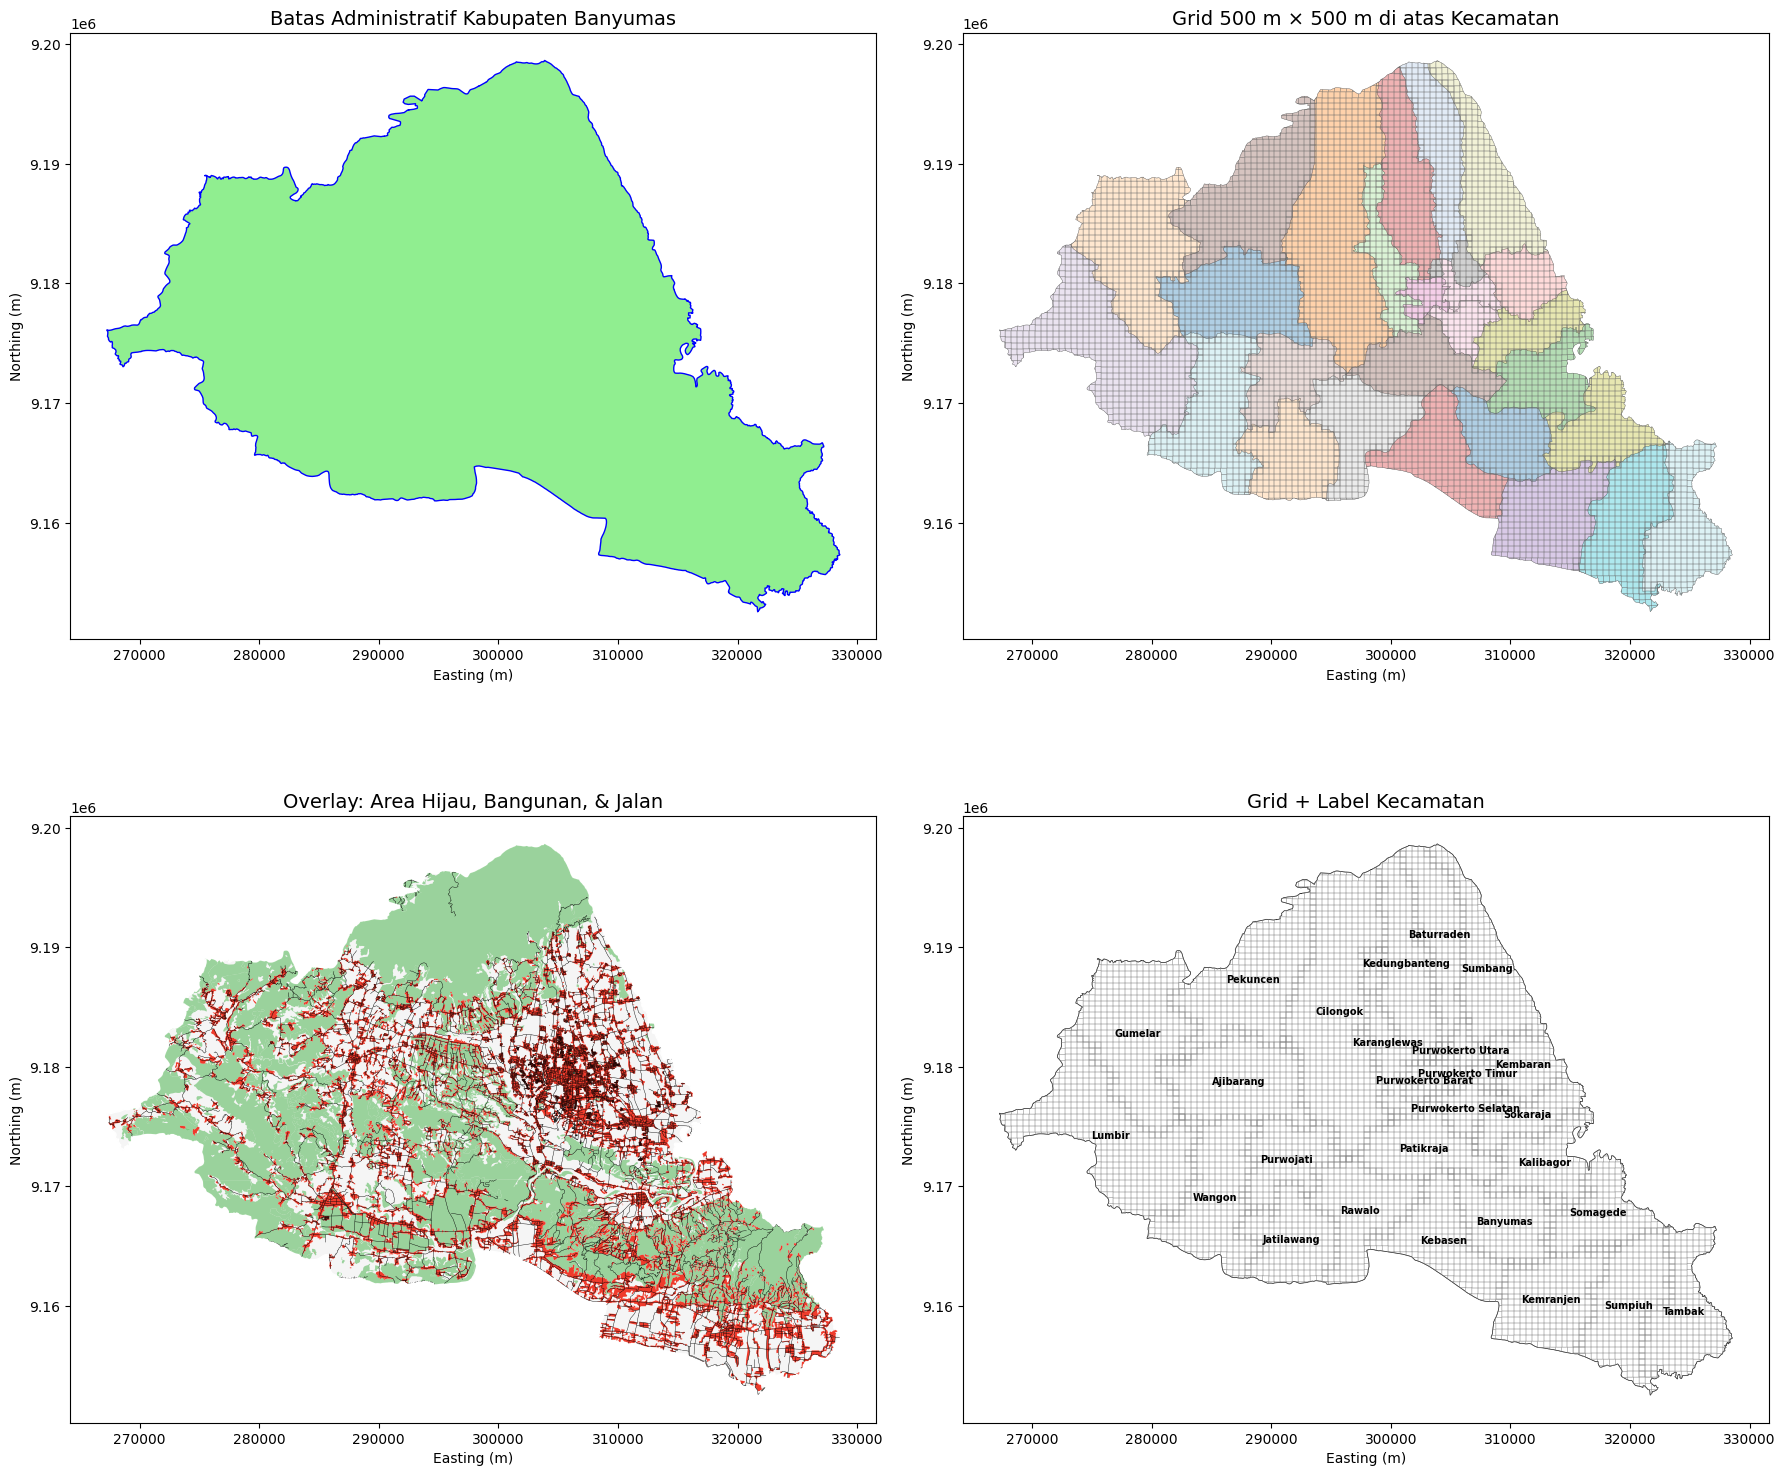

✅ grid_with_kec siap. Kolom tersedia: ['GID_3', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'GID_2', 'NL_NAME_2', 'NAME_3_left', 'VARNAME_3', 'NL_NAME_3', 'TYPE_3', 'ENGTYPE_3', 'CC_3', 'HASC_3', 'geometry', 'grid_id', 'cell_area_m2', 'NAME_3_right', 'kecamatan']


In [36]:
# ==== SAFETY GUARD: siapkan banyumas_kab & bms_boundary kalau belum ada ====
try:
    _ = banyumas_kab  # cek sudah ada?
except NameError:
    # >>> GANTI path ini jika perlu <<<
    banyumas_shp = r"E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\indonesiaSHPLevel3\gadm41_IDN_3.shp"

    banyumas_kab = gpd.read_file(banyumas_shp)
    # filter ke Kab. Banyumas dan set CRS proyek (UTM 49S)
    assert "NAME_2" in banyumas_kab.columns, "Kolom 'NAME_2' tidak ada di shapefile Level-3."
    banyumas_kab = banyumas_kab[banyumas_kab["NAME_2"] == "Banyumas"].to_crs(epsg=32749)

try:
    _ = bms_boundary
except NameError:
    # dissolve jadi boundary kabupaten
    bms_boundary = banyumas_kab.dissolve(by="NAME_2")

# ==== VALIDASI GRID ====
try:
    _ = grid
except NameError:
    raise NameError("Variabel 'grid' belum dibuat. Jalankan dulu cell 'Convert to Grid' yang membuat grid GeoDataFrame.")

# ==== CLIP LAYER-LAYER KE BANYUMAS (pakai nama konsisten *_bms) ====
# Pastikan area_hijau, bangunan, jalan sudah ada; kalau belum, beri pesan jelas
for _var in ["area_hijau", "bangunan", "jalan"]:
    if _var not in locals():
        raise NameError(f"Variabel '{_var}' belum ada. Pastikan sudah load dari GDB sebelumnya.")

area_hijau_bms = gpd.clip(area_hijau, bms_boundary)
bangunan_bms   = gpd.clip(bangunan,   bms_boundary)
jalan_bms      = gpd.clip(jalan,      bms_boundary)

# ==== PLOT 2x2 ====
fig, axs = plt.subplots(2, 2, figsize=(18, 16))

# (A) Batas Administratif
bms_boundary.plot(ax=axs[0, 0], color="lightgreen", edgecolor="blue")
axs[0, 0].set_title("Batas Administratif Kabupaten Banyumas", fontsize=14)
axs[0, 0].set_xlabel("Easting (m)"); axs[0, 0].set_ylabel("Northing (m)")

# (B) Grid di atas warna kecamatan
banyumas_kab.plot(
    ax=axs[0, 1],
    column="NAME_3", cmap="tab20", alpha=0.35,
    edgecolor="black", linewidth=0.3
)
grid.boundary.plot(ax=axs[0, 1], color="dimgray", linewidth=0.2)
axs[0, 1].set_title("Grid 500 m × 500 m di atas Kecamatan", fontsize=14)
axs[0, 1].set_xlabel("Easting (m)"); axs[0, 1].set_ylabel("Northing (m)")
axs[0, 1].set_aspect("equal")

# (C) Overlay Jalan + Bangunan + Area Hijau
bms_boundary.plot(ax=axs[1, 0], color="#f5f5f5", edgecolor="white")
area_hijau_bms.plot(ax=axs[1, 0], color="#74c476", alpha=0.7)     # hijau
bangunan_bms.plot(ax=axs[1, 0], color="#ef3b2c", markersize=0.2)  # merah
jalan_bms.plot(ax=axs[1, 0], color="black", linewidth=0.3)        # hitam
axs[1, 0].set_title("Overlay: Area Hijau, Bangunan, & Jalan", fontsize=14)
axs[1, 0].set_xlabel("Easting (m)"); axs[1, 0].set_ylabel("Northing (m)")
axs[1, 0].set_aspect("equal")

# (D) Grid + label kecamatan
bms_boundary.plot(ax=axs[1, 1], color="white", edgecolor="black", linewidth=0.5)
grid.boundary.plot(ax=axs[1, 1], color="gray", linewidth=0.2)
for _, row in banyumas_kab.iterrows():
    c = row.geometry.centroid
    axs[1, 1].text(c.x, c.y, str(row["NAME_3"]), fontsize=7, ha="center", va="center", weight="bold", color="black")
axs[1, 1].set_title("Grid + Label Kecamatan", fontsize=14)
axs[1, 1].set_xlabel("Easting (m)"); axs[1, 1].set_ylabel("Northing (m)")
axs[1, 1].set_aspect("equal")

plt.tight_layout(); plt.show()

# ==== SPATIAL JOIN: atribut kecamatan -> grid ====
KecamatanCol = "NAME_3"
assert KecamatanCol in banyumas_kab.columns, f"Kolom '{KecamatanCol}' tidak ditemukan. Kolom tersedia: {banyumas_kab.columns.tolist()}"

grid = grid.copy()
grid["grid_id"] = np.arange(1, len(grid) + 1)

grid_with_kec = gpd.sjoin(
    grid,
    banyumas_kab[[KecamatanCol, "geometry"]],
    how="left",
    predicate="intersects"
).rename(columns={KecamatanCol: "kecamatan"}).drop(columns=["index_right"])

print("✅ grid_with_kec siap. Kolom tersedia:", grid_with_kec.columns.tolist())


In [37]:
# === BANGUN FITUR & LABEL untuk BANYUMAS ===
# (pakai grid yang sudah kamu buat; fungsi akan menambahkan 'kecamatan' kalau belum ada)
feat = build_grid_features(
    grid=grid,                # atau grid_with_kec; dua-duanya oke
    adm_kecamatan=bms_adm,    # admin Banyumas level-3 yang sudah to_crs(32749)
    bangunan=bangunan_bms,
    area_hijau=area_hijau_bms,
    jalan=jalan_bms
)
feat = label_emission(feat, out_dir=OUT)   # ini juga nyimpan grid_features_labeled.csv
feat["wilayah"] = "Banyumas"

print("✅ Banyumas feat siap:", feat.shape, "kolom:", list(feat.columns)[:10])


✅ Tersimpan: E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\outputs\grid_features_labeled.csv
✅ Banyumas feat siap: (9216, 15) kolom: ['grid_id', 'kecamatan', 'cell_area_m2', 'geometry', 'bangunan_m2', 'hijau_m2', 'jalan_m', 'road_km_per_km2', 'building_area_pct', 'green_area_pct']


3) FEATURE ENGINEERING → variabel numerik per grid
    (luas hijau, luas bangunan, panjang jalan + turunan)

In [38]:
import geopandas as gpd
import pandas as pd
import numpy as np

def _require_gdf(x, name):
    if x is None:
        raise ValueError(f"Layer '{name}' belum diisi (None). Berikan GeoDataFrame yang valid.")
    if not isinstance(x, gpd.GeoDataFrame):
        raise TypeError(f"Layer '{name}' harus GeoDataFrame, bukan {type(x)}.")
    if x.empty:
        raise ValueError(f"Layer '{name}' kosong.")
    if "geometry" not in x.columns:
        raise ValueError(f"Layer '{name}' tidak memiliki kolom 'geometry'.")
    return x

def _to_metric_crs_like(target_gdf, *others):
    """Samakan semua CRS ke CRS metrik (estimasi UTM dari 'target_gdf')."""
    if target_gdf.crs is None:
        raise ValueError("GeoDataFrame target tidak memiliki CRS. Tetapkan CRS (mis. EPSG:4326) terlebih dulu.")
    metric_crs = target_gdf.estimate_utm_crs() or target_gdf.crs
    tgt = target_gdf.to_crs(metric_crs)
    out = [o.to_crs(metric_crs) if o.crs != metric_crs else o for o in others]
    return (tgt, *out)

def _detect_kecamatan_col(adm_gdf):
    kandidat = ["kecamatan", "KECAMATAN", "NamaKec", "NAME_4", "NAME_3", "WADMKC"]
    ada = [c for c in kandidat if c in adm_gdf.columns]
    if not ada:
        raise KeyError(
            "Tidak menemukan kolom nama kecamatan pada layer administrasi. "
            f"Kolom yang tersedia: {list(adm_gdf.columns)}.\n"
            "Tambahkan/rename dulu salah satu kolom menjadi salah satu dari "
            f"{kandidat}."
        )
    return ada[0]

def build_grid_features(grid, adm_kecamatan, bangunan, area_hijau, jalan):
    """
    Menghasilkan tabel fitur per grid:
      - bangunan_m2, hijau_m2, jalan_m
      - turunan: road_km_per_km2, building_area_pct, green_area_pct,
                 ratio_green_building, ratio_road_building
      - kolom 'kecamatan' hasil spatial join
    """
    # 0) Validasi input
    grid         = _require_gdf(grid, "grid")
    adm_kecamatan= _require_gdf(adm_kecamatan, "adm_kecamatan")
    bangunan     = _require_gdf(bangunan, "bangunan")
    area_hijau   = _require_gdf(area_hijau, "area_hijau")
    jalan        = _require_gdf(jalan, "jalan")

    # 1) Samakan CRS ke metrik (UTM estimasi dari grid) agar area/length valid
    grid, adm_kecamatan, bangunan, area_hijau, jalan = _to_metric_crs_like(
        grid, adm_kecamatan, bangunan, area_hijau, jalan
    )

    # 2) grid_id & luas sel
    if "grid_id" not in grid.columns:
        grid = grid.copy()
        grid["grid_id"] = np.arange(1, len(grid) + 1)
    if "cell_area_m2" not in grid.columns:
        grid = grid.copy()
        grid["cell_area_m2"] = grid.geometry.area

    # 3) Tambahkan kolom kecamatan via sjoin (kalau belum ada)
    if "kecamatan" not in grid.columns:
        kec_col = _detect_kecamatan_col(adm_kecamatan)
        joined = gpd.sjoin(
            grid[["grid_id", "cell_area_m2", "geometry"]],
            adm_kecamatan[[kec_col, "geometry"]],
            how="left",
            predicate="intersects"
        )
        # Bersihkan kolom sisa sjoin & rename
        for c in ["index_right", "index_left"]:
            if c in joined.columns:
                joined = joined.drop(columns=c)
        joined = joined.rename(columns={kec_col: "kecamatan"})
        grid = joined

    # 4) Overlay/intersection per tema
    #    Catatan: jika ada geometri invalid, perbaiki cepat dengan buffer(0)
    def _fix_valid(gdf):
        try:
            return gdf.set_geometry(gdf.geometry.buffer(0))
        except Exception:
            return gdf

    bangunan   = _fix_valid(bangunan)
    area_hijau = _fix_valid(area_hijau)
    # Untuk jalan (LineString), tak perlu buffer(0) biasanya

    # Bangunan polygon → luas per grid
    bgn_clip = gpd.overlay(bangunan, grid[["grid_id", "geometry"]], how="intersection")
    if not bgn_clip.empty:
        bgn_clip["bangunan_m2"] = bgn_clip.geometry.area
        feat_bgn = bgn_clip.groupby("grid_id", as_index=False)["bangunan_m2"].sum()
    else:
        feat_bgn = pd.DataFrame({"grid_id": grid["grid_id"], "bangunan_m2": 0.0})

    # Hijau polygon → luas per grid
    hj_clip = gpd.overlay(area_hijau, grid[["grid_id", "geometry"]], how="intersection")
    if not hj_clip.empty:
        hj_clip["hijau_m2"] = hj_clip.geometry.area
        feat_hj = hj_clip.groupby("grid_id", as_index=False)["hijau_m2"].sum()
    else:
        feat_hj = pd.DataFrame({"grid_id": grid["grid_id"], "hijau_m2": 0.0})

    # Jalan line → panjang per grid
    jln_clip = gpd.overlay(jalan, grid[["grid_id", "geometry"]], how="intersection")
    if not jln_clip.empty:
        jln_clip["jalan_m"] = jln_clip.geometry.length
        feat_jln = jln_clip.groupby("grid_id", as_index=False)["jalan_m"].sum()
    else:
        feat_jln = pd.DataFrame({"grid_id": grid["grid_id"], "jalan_m": 0.0})

    # 5) Gabungkan fitur ke grid
    feat = (
        grid[["grid_id", "kecamatan", "cell_area_m2", "geometry"]]
        .merge(feat_bgn, on="grid_id", how="left")
        .merge(feat_hj,  on="grid_id", how="left")
        .merge(feat_jln, on="grid_id", how="left")
    )

    for c in ["bangunan_m2", "hijau_m2", "jalan_m"]:
        if c not in feat.columns:
            feat[c] = 0.0
        feat[c] = pd.to_numeric(feat[c], errors="coerce").fillna(0.0)

    # 6) Variabel turunan (dengan proteksi div-by-zero)
    eps = 1.0  # untuk mencegah pembagian nol pada rasio berbasis bangunan
    feat["road_km_per_km2"]     = (feat["jalan_m"] / 1000.0) / (feat["cell_area_m2"] / 1e6).replace({0: np.nan})
    feat["building_area_pct"]   = (feat["bangunan_m2"] / feat["cell_area_m2"].replace({0: np.nan})) * 100.0
    feat["green_area_pct"]      = (feat["hijau_m2"]    / feat["cell_area_m2"].replace({0: np.nan})) * 100.0
    feat["ratio_green_building"]= feat["hijau_m2"] / (feat["bangunan_m2"] + eps)
    feat["ratio_road_building"] = feat["jalan_m"]  / (feat["bangunan_m2"] + eps)

    # Jika ada NaN dari pembagian oleh 0 area sel, set 0 saja
    feat[["road_km_per_km2", "building_area_pct", "green_area_pct"]] = \
        feat[["road_km_per_km2", "building_area_pct", "green_area_pct"]].fillna(0.0)

    return feat



4) LABELING → kelas emisi (Rendah/Sedang/Tinggi)
    skor emisi berbasis normalisasi robust p99 (menghindari outlier)

In [39]:
def label_emission(feat: pd.DataFrame, out_dir=None,
                   alpha=0.3, beta=0.4, gamma=0.3, p=99):
    
    # 0) Validasi input
    if not isinstance(feat, (pd.DataFrame, gpd.GeoDataFrame)):
        raise TypeError("feat harus DataFrame/GeoDataFrame hasil fitur grid.")

    req = ["road_km_per_km2", "building_area_pct", "green_area_pct"]
    miss = [c for c in req if c not in feat.columns]
    if miss:
        raise KeyError(f"Kolom wajib hilang: {miss}. Pastikan blok fitur sudah dijalankan.")

    feat = feat.copy()

    # 1) Normalisasi robust (p99) agar outlier tidak mendominasi
    def robust_norm(series, p=p):
        s = pd.to_numeric(series, errors="coerce").fillna(0.0)
        cap = np.nanpercentile(s, p)
        if not np.isfinite(cap) or cap <= 0:
            # semua nol atau tidak valid → kembalikan nol
            return np.zeros_like(s, dtype=float)
        return np.clip(s / cap, 0.0, 1.0)

    rn_road  = robust_norm(feat["road_km_per_km2"])
    rn_build = robust_norm(feat["building_area_pct"])
    rn_green = robust_norm(feat["green_area_pct"])

    # 2) Skor emisi (jalan + bangunan menambah, hijau mengurangi)
    feat["score"] = alpha * rn_road + beta * rn_build - gamma * rn_green

    # 3) Threshold tertile (fallback bila varian nol)
    s = feat["score"].astype(float)
    if s.nunique() <= 1:
        # semua sama → taruh "Sedang" supaya tidak kosong
        feat["kategori_emisi"] = "Sedang"
    else:
        q1, q2 = s.quantile([1/3, 2/3]).tolist()
        feat["kategori_emisi"] = pd.cut(
            s,
            bins=[-np.inf, q1, q2, np.inf],
            labels=["Rendah", "Sedang", "Tinggi"],
            include_lowest=True,
            right=True
        ).astype(str)

    # 4) Simpan (opsional)
    if out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        out_csv = out_dir / "grid_features_labeled.csv"
        # Drop geometry jika ada
        to_save = feat.drop(columns=["geometry"], errors="ignore")
        to_save.to_csv(out_csv, index=False, encoding="utf-8-sig")
        print(f"✅ Tersimpan: {out_csv}")

    return feat

PROSES WILAYAH TAMBAHAN & MERGE SEBELUM SPLIT

In [40]:
# ---- util: pick layer yang ada di GDB (nama layer RBI kadang beda tipis) ----
def pick_layer(gdb_path, candidates):
    avail = set(fiona.listlayers(str(gdb_path)))
    for c in candidates:
        if c in avail:
            return c
    raise FileNotFoundError(f"Tidak menemukan layer dari {candidates} di {gdb_path}.\nTersedia: {sorted(avail)}")

# ---- util: proses satu wilayah end-to-end ----
def process_region(region_name, selector: dict, gdb_path: Path, grid_size=500):
    # 1) ambil admin boundary level-3 sesuai selector (mis. {"NAME_2":"Kota Yogyakarta"})
    adm_all = gpd.read_file(GADM)
    adm_sel = adm_all.copy()
    for k, v in selector.items():
        adm_sel = adm_sel[adm_sel[k] == v]
    if adm_sel.empty:
        raise ValueError(f"Boundary kosong untuk selector: {selector}")

    # gunakan CRS metrik lokal (estimasi UTM dari boundary)
    metric_crs = adm_sel.estimate_utm_crs() or adm_sel.crs
    adm_sel = adm_sel.to_crs(metric_crs)
    boundary = adm_sel.dissolve(by=list(selector.keys())[0])  # dissolve per kab/kota

    # 2) bangun grid
    minx, miny, maxx, maxy = boundary.total_bounds
    cols = np.arange(minx, maxx, grid_size)
    rows = np.arange(miny, maxy, grid_size)
    cells = [box(x, y, x+grid_size, y+grid_size) for x in cols for y in rows]
    grid = gpd.GeoDataFrame({"geometry": cells}, crs=metric_crs)
    grid = gpd.overlay(grid, boundary, how="intersection").reset_index(drop=True)
    grid["grid_id"] = np.arange(1, len(grid)+1)
    grid["cell_area_m2"] = grid.geometry.area

    # 3) join atribut kecamatan (deteksi otomatis di build_grid_features)
    #    -> dilakukan di dalam build_grid_features jika 'kecamatan' belum ada

    # 4) baca layer dari GDB wilayah (robust pick)
    lyr_hijau = pick_layer(gdb_path, [
        "HUTANLAHANTINGGI_AR_25K","HUTANLAHANRENDAH_AR_25K",
        "HERBADANRUMPUT_AR_25K","HUTANTANAMAN_AR_25K",
        # fallback umum
        "TUTUPANLAHAN_AR_25K","PENUTUPANLAHAN_AR_25K"
    ])
    # beberapa GDB memecah hijau jadi banyak layer; kalau ada beberapa, concat saja
    # untuk robust sederhana: kalau ada hanya satu "hijau", pakai itu
    # (kalau kamu tahu daftar tepat per GDB, ganti bagian ini sesuai kebutuhan)
    area_hijau = gpd.read_file(gdb_path, layer=lyr_hijau).to_crs(metric_crs)

    lyr_bgn = pick_layer(gdb_path, [
        "PERUMAHAN_AR_25K","PERMUKIMAN_AR_25K",
        "BANGUNAN_AR_25K","BANGUNAN_PT_25K"  # fallback
    ])
    bangunan = gpd.read_file(gdb_path, layer=lyr_bgn).to_crs(metric_crs)

    lyr_jln = pick_layer(gdb_path, ["JALAN_LN_25K","JARINGANJALAN_LN_25K"])
    jalan   = gpd.read_file(gdb_path, layer=lyr_jln).to_crs(metric_crs)

    # 5) bangun fitur & label (pakai fungsi yang SUDAH kamu definisikan)
    feat_r = build_grid_features(grid, adm_sel, bangunan, area_hijau, jalan)
    feat_r = label_emission(feat_r)
    feat_r["wilayah"] = region_name

    # simpan versi CSV tanpa geometry (arsip per wilayah)
    feat_r.drop(columns=["geometry"], errors="ignore") \
          .to_csv(OUT / "per_region" / f"{region_name}_features_labeled.csv",
                  index=False, encoding="utf-8-sig")
    print(f"✅ {region_name}: {len(feat_r)} grid → tersimpan di per_region/")
    return feat_r

# ==== JALANKAN untuk Yogyakarta & Jakarta Pusat ====
feat_yogya  = process_region("Yogyakarta",  {"NAME_2":"Kota Yogyakarta"}, GDB_YOGYA, grid_size=500)
feat_jakpus = process_region("JakartaPusat",{"NAME_2":"Jakarta Pusat"},  GDB_JAKPUS, grid_size=500)

# ==== GABUNG DENGAN BANYUMAS YANG SUDAH ADA DI VAR 'feat' ====
# pastikan feat Banyumas punya kolom wilayah
feat_bms = feat.copy()
if "wilayah" not in feat_bms.columns:
    feat_bms["wilayah"] = "Banyumas"

# samakan nama kolom penting bila perlu
alias_map = {
    "emission_label": "kategori_emisi",
    "prediksi_kategori": "kategori_emisi",
    "road_density_km_per_km2": "road_km_per_km2",
    "building_density_per_km2": "building_area_pct",
    "green_percent": "green_area_pct",
}
feat_bms = feat_bms.rename(columns={k:v for k,v in alias_map.items() if k in feat_bms.columns})

# gabung
feat = pd.concat([
    feat_bms.drop(columns=["geometry"], errors="ignore"),
    feat_yogya.drop(columns=["geometry"], errors="ignore"),
    feat_jakpus.drop(columns=["geometry"], errors="ignore"),
], ignore_index=True)

print("\n🔎 Rekap gabungan per wilayah:")
print(feat.groupby(["wilayah","kategori_emisi"])["grid_id"].count().unstack(fill_value=0))

# (opsional) simpan dataset gabungan
feat.to_csv(OUT / "merged_features_labeled_all.csv", index=False, encoding="utf-8-sig")
print(f"\n💾 Tersimpan gabungan: {OUT/'merged_features_labeled_all.csv'}")

✅ Yogyakarta: 511 grid → tersimpan di per_region/
✅ JakartaPusat: 822 grid → tersimpan di per_region/

🔎 Rekap gabungan per wilayah:
kategori_emisi  Rendah  Sedang  Tinggi
wilayah                               
Banyumas          3075    3069    3072
JakartaPusat       274     281     267
Yogyakarta         172     169     170

💾 Tersimpan gabungan: E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\outputs\merged_features_labeled_all.csv


5) EDA & BALANCING → distribusi label, data balanced
    (CATATAN: balancing DITERAPKAN nanti HANYA di TRAIN → anti leakage)

Sebelum split (setelah labeling) → untuk memvalidasi data dan memutuskan apakah perlu balancing/penyesuaian fitur.

road_km_per_km2         0
building_area_pct       0
green_area_pct          0
ratio_green_building    0
ratio_road_building     0
dtype: int64
road_km_per_km2         4512
building_area_pct       3967
green_area_pct          3165
ratio_green_building    3305
ratio_road_building     4512
dtype: int64


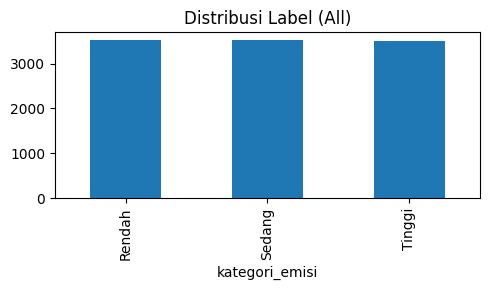

kategori_emisi,Rendah,Sedang,Tinggi
kecamatan,,,
Cilongok,369,276,143
Lumbir,338,200,50
Gumelar,302,178,62
Pekuncen,237,163,95
Kedungbanteng,199,115,84
Baturraden,182,68,84
Rawalo,172,122,56
Ajibarang,162,147,141
Wangon,161,179,104


,road_km_per_km2,building_area_pct,green_area_pct,ratio_green_building,ratio_road_building
count,10549.000,10549.000,10549.000,10549.000,10549.000
mean,8.471,27.169,60.705,76692.644,936.416
std,17.574,40.384,70.745,160735.259,2664.237
min,0.000,0.000,0.000,0.000,0.000
50%,3.980,8.560,34.807,1.147,0.014
90%,25.971,78.191,188.626,250000.000,3951.595
95%,36.005,111.988,200.000,500000.000,8102.540
99%,52.116,180.680,254.307,500000.000,12202.737
max,879.254,260.251,400.000,1000000.000,17846.281


In [41]:
# 1) Cek null/konstan
num_cols = ["road_km_per_km2","building_area_pct","green_area_pct",
            "ratio_green_building","ratio_road_building"]
print(feat[num_cols].isna().sum())           # NA check
print(feat[num_cols].nunique())              # fitur konstan?

# 2) Distribusi label keseluruhan
ax = (feat["kategori_emisi"]
      .value_counts()
      .reindex(["Rendah","Sedang","Tinggi"])
      .fillna(0)
      .plot(kind="bar", figsize=(5,3), title="Distribusi Label (All)"))
plt.tight_layout(); plt.show()

# 3) Distribusi label per-kecamatan (top 10 biar ringkas)
tmp = (feat.groupby(["kecamatan","kategori_emisi"])["grid_id"]
          .count().unstack(fill_value=0))
display(tmp.sort_values(tmp.columns.tolist(), ascending=False).head(10))

# 4) Ringkas statistik fitur (untuk mengonfirmasi p99 clipping efektif)
display(feat[num_cols].describe(percentiles=[.5,.9,.95,.99]).round(3))


6) SPLITTING → train/test per kecamatan (hold-out kecamatan)

In [47]:
# ==== SPLITTING PER WILAYAH (untuk dataset gabungan) ====
TRAIN_REGION = ["Banyumas", "Yogyakarta"]
TEST_REGION  = ["JakartaPusat"]

df_train = feat[feat["wilayah"].isin(TRAIN_REGION)].copy()
df_test  = feat[feat["wilayah"].isin(TEST_REGION)].copy()

assert (len(df_train) > 0) and (len(df_test) > 0), "Split kosong — cek nama wilayah dan kolom 'wilayah' di dataset."

# ==== PASTIKAN NAMA KOLOM FITUR ====
FEATURES = ["hijau_m2", "bangunan_m2", "jalan_m", "ratio_green_building", "ratio_road_building"]

# ---- alias/rename kalau perlu (sama seperti sebelumnya) ----
def alias(df, targets):
    for name in targets:
        if name in df.columns:
            return name
    return None

rename_pairs = {}
for src, dsts in {
    "hijau_m2": ["hijau_m2", "luas_hijau_m2", "green_m2"],
    "bangunan_m2": ["bangunan_m2", "luas_bangunan_m2", "building_m2"],
    "jalan_m": ["jalan_m", "panjang_jalan_m", "road_m"],
}.items():
    found = alias(feat, dsts)
    if found and found != src:
        rename_pairs[found] = src

if rename_pairs:
    feat = feat.rename(columns=rename_pairs)

# ==== BUAT RASIO JIKA BELUM ADA ====
if "ratio_green_building" not in feat.columns:
    feat["ratio_green_building"] = feat["hijau_m2"] / (feat["bangunan_m2"] + 1.0)
if "ratio_road_building" not in feat.columns:
    feat["ratio_road_building"] = feat["jalan_m"] / (feat["bangunan_m2"] + 1.0)

# ==== CEK TARGET ====
if "kategori_emisi" not in feat.columns:
    raise KeyError("Kolom 'kategori_emisi' tidak ditemukan — pastikan sudah lewat proses labeling.")

# ==== SIAPKAN DATA NUMERIK UNTUK MODEL ====
X_train = df_train[FEATURES].astype(float).fillna(0.0).values
y_train = df_train["kategori_emisi"].astype(str).values

X_test = df_test[FEATURES].astype(float).fillna(0.0).values
y_test = df_test["kategori_emisi"].astype(str).values

print("Distribusi TRAIN per wilayah:")
print(df_train["wilayah"].value_counts())
print("\nDistribusi label TRAIN:", pd.Series(y_train).value_counts().to_dict())

print("\nDistribusi TEST per wilayah:")
print(df_test["wilayah"].value_counts())
print("\nDistribusi label TEST :", pd.Series(y_test).value_counts().to_dict())


Distribusi TRAIN per wilayah:
wilayah
Banyumas      9216
Yogyakarta     511
Name: count, dtype: int64

Distribusi label TRAIN: {'Rendah': 3247, 'Tinggi': 3242, 'Sedang': 3238}

Distribusi TEST per wilayah:
wilayah
JakartaPusat    822
Name: count, dtype: int64

Distribusi label TEST : {'Sedang': 281, 'Rendah': 274, 'Tinggi': 267}


CEK DATA BALANCE ATAU NGGA

In [48]:
def quick_summary(train_df, test_df, label_col="emission_category", feats=["road_density_km_per_km2","building_density_per_km2","green_percent"]):
    print("== Size ==")
    print("Train:", len(train_df), "Test:", len(test_df))
    print("\n== Label counts (train) ==")
    print(train_df[label_col].value_counts(), "\n")
    print("== Label counts (test) ==")
    print(test_df[label_col].value_counts(), "\n")
    
    print("== Label % (train) ==")
    print((train_df[label_col].value_counts(normalize=True)*100).round(2).astype(str) + "%\n")
    print("== Label % (test) ==")
    print((test_df[label_col].value_counts(normalize=True)*100).round(2).astype(str) + "%\n")
    
    print("== Feature summary (train) ==")
    print(train_df[feats].describe().T[['count','mean','std','min','50%','max']])
    print("\n== Feature summary (test) ==")
    print(test_df[feats].describe().T[['count','mean','std','min','50%','max']])
    
    print("\n== Samples per kecamatan (train) ==")
    print(train_df['kecamatan'].value_counts())
    print("\n== Samples per kecamatan (test) ==")
    print(test_df['kecamatan'].value_counts())

quick_summary(df_train, df_test, 
              label_col="kategori_emisi",
              feats=["road_km_per_km2","building_area_pct","green_area_pct"])


== Size ==
Train: 9727 Test: 822

== Label counts (train) ==
kategori_emisi
Rendah    3247
Tinggi    3242
Sedang    3238
Name: count, dtype: int64 

== Label counts (test) ==
kategori_emisi
Sedang    281
Rendah    274
Tinggi    267
Name: count, dtype: int64 

== Label % (train) ==
kategori_emisi
Rendah    33.38%\n
Tinggi    33.33%\n
Sedang    33.29%\n
Name: proportion, dtype: object
== Label % (test) ==
kategori_emisi
Sedang    34.18%\n
Rendah    33.33%\n
Tinggi    32.48%\n
Name: proportion, dtype: object
== Feature summary (train) ==
                    count       mean        std  min        50%         max
road_km_per_km2    9727.0   6.446046  16.214464  0.0   3.438188  879.253536
building_area_pct  9727.0  29.465116  41.243440  0.0  13.267576  260.251047
green_area_pct     9727.0  65.834761  71.344262  0.0  50.387459  400.000000

== Feature summary (test) ==
                   count       mean        std  min       50%        max
road_km_per_km2    822.0  32.433304  15.164571  0.0 

EDA Sesudah split 
→ untuk cek sanity bahwa train/test “fair” (nggak ada pergeseran distribusi besar atau kebocoran).

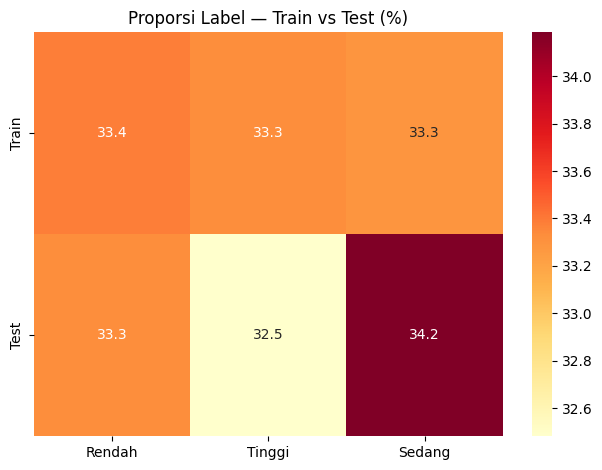

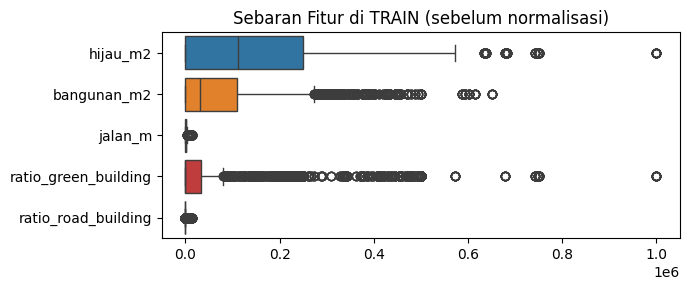

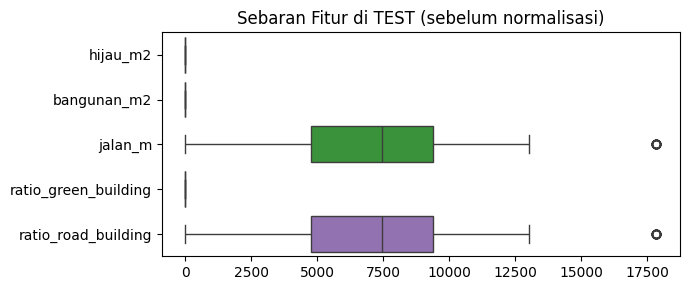

In [49]:
# 5) Bandingkan distribusi label train vs test
import seaborn as sns, pandas as pd, matplotlib.pyplot as plt

train_counts = pd.Series(y_train).value_counts().rename("Train")
test_counts  = pd.Series(y_test).value_counts().rename("Test")
distrib = pd.concat([train_counts, test_counts], axis=1).fillna(0)
distrib_pct = distrib.div(distrib.sum(axis=0), axis=1)*100
sns.heatmap(distrib_pct.T, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Proporsi Label — Train vs Test (%)"); plt.tight_layout(); plt.show()

# 6) Cek pergeseran fitur utama (boxplot sederhana)
plt.figure(figsize=(7,3))
sns.boxplot(data=pd.DataFrame(X_train, columns=FEATURES), orient="h")
plt.title("Sebaran Fitur di TRAIN (sebelum normalisasi)"); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,3))
sns.boxplot(data=pd.DataFrame(X_test, columns=FEATURES), orient="h")
plt.title("Sebaran Fitur di TEST (sebelum normalisasi)"); plt.tight_layout(); plt.show()


7) NORMALISASI → data siap model (fit scaler di TRAIN saja)
    (Balancing → setelah split, sebelum fit model)

In [53]:
# Normalisasi fit di TRAIN_BAL lalu transform TEST
scaler = StandardScaler(with_mean=True, with_std=True)
X_train_std = scaler.fit_transform(X_train_bal)
X_test_std  = scaler.transform(X_test)

# Label encoding untuk evaluasi/plot
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_bal)
y_test_enc  = le.transform(y_test)
classes = list(le.classes_)  # ['Rendah','Sedang','Tinggi']

8) MODELING (SVM) → model terlatih

In [54]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.1, 0.01, 0.001],
    "kernel": ["rbf"]
}
svm = SVC(probability=True, class_weight=None, random_state=42)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(svm, param_grid, scoring="f1_macro", cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train_std, y_train_enc)

best_svm = gs.best_estimator_
print("[BEST PARAMS]:", gs.best_params_)
print("[CV F1_MACRO]:", round(gs.best_score_, 4))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[BEST PARAMS]: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
[CV F1_MACRO]: 0.9652


9) EVALUATION → F1, Confusion Matrix, Accuracy


Akurasi  : 0.5389
F1-Macro : 0.5187

=== Classification Report ===
              precision    recall  f1-score   support

      Rendah       0.79      0.27      0.41       274
      Sedang       0.38      0.47      0.42       281
      Tinggi       0.62      0.88      0.73       267

    accuracy                           0.54       822
   macro avg       0.60      0.54      0.52       822
weighted avg       0.59      0.54      0.52       822



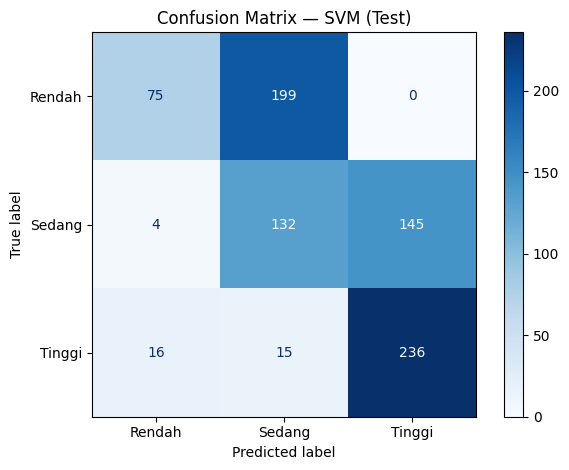

✅ Tersimpan: E:\KULIAH SEMESTER 7\COMPUTING PROJECT\CAPSTONEPROJECT\outputs\prediksi_grid_test_svm.csv


In [55]:
y_pred_enc = best_svm.predict(X_test_std)
y_pred     = [classes[i] for i in y_pred_enc]

acc  = accuracy_score(y_test_enc, y_pred_enc)
f1m  = f1_score(y_test_enc, y_pred_enc, average="macro")
print(f"\nAkurasi  : {acc:.4f}")
print(f"F1-Macro : {f1m:.4f}\n")
print("=== Classification Report ===")
print(classification_report(y_test_enc, y_pred_enc, target_names=classes))

# Confusion Matrix (biarkan seperti kode kamu)
ConfusionMatrixDisplay.from_predictions(y_test_enc, y_pred_enc, display_labels=classes, cmap="Blues")
plt.title("Confusion Matrix — SVM (Test)")
plt.tight_layout(); plt.show()

# Simpan hasil prediksi per-grid test (ignore jika 'geometry' memang tidak ada)
pred_df = df_test.reset_index(drop=True).copy()
pred_df["prediksi_kategori"] = y_pred

OUT.mkdir(parents=True, exist_ok=True)  # pastikan folder ada
pred_df.drop(columns=["geometry"], errors="ignore") \
       .to_csv(OUT / "prediksi_grid_test_svm.csv", index=False, encoding="utf-8-sig")

print(f"✅ Tersimpan: {OUT/'prediksi_grid_test_svm.csv'}")
